# Experiment on DL Model

### This notebook involves preprocessing data along with the training workflow of the deep learning model


In [1]:
# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# for data preprocessing
import pandas as pd
import numpy as np
import ast
import copy
import re
import scipy.stats as stats

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Data Preprocessing


In [2]:
# Import dataset
data = pd.read_csv("../data/pokemon-cards.csv", delimiter=",")

In [3]:
# Remove unnecessary columns
colToDrop = ['id','publisher', 'release_date', 'name', 'set_num', 'nationalPokedexNumbers',
             'flavorText', 'legalities', 'retreatCost', 'rules', 'evolvesFrom', 'evolvesTo', 'resistances', 'ancientTrait',
             'artist', 'abilities', 'weaknesses', 'set', 'level', 'subtypes', 'supertype', 'regulationMark', 'generation']
data = data.drop(labels=colToDrop, axis=1)

# Deal with NaN 
data = data.dropna(subset=['attacks', 'rarity', 'hp'])
data = data.rename(columns={'convertedRetreatCost': 'retreat_cost'})
data['retreat_cost'] = data['retreat_cost'].fillna(0)

In [4]:
# Turned 'attacks' column into max_damage,numAttacks
def preprocess_attacks(data):
    max_damages = []
    num_attacks = []

    for val in data['attacks']:
        try:
            attack_list = ast.literal_eval(val)
            damages = [parse_damage(attack.get('damage', '')) for attack in attack_list]

            max_damages.append(max(damages) if damages else 0)
            num_attacks.append(len(attack_list))

        except:
            max_damages.append(0)
            num_attacks.append(0)

    data['max_damage'] = max_damages
    data['num_attacks'] = num_attacks
    data = data.drop(columns='attacks')
    return data

def parse_damage(dmg_str):
    dmg_str = dmg_str.strip()

    # Extract all numeric parts
    numbers = re.findall(r'\d+', dmg_str)
    numbers = list(map(float, numbers))

    if not numbers:
        return 0.0
    elif any(op in dmg_str for op in ['+', '×', 'x']):
        return sum(numbers)  # e.g., '30+20' → 50
    else:
        return numbers[0]  # e.g., '100' → 100

In [ ]:
# One-Hot Encode data column
def preprocess_types(data):
    # filter-OUT 2-attribute observations
    data = data.loc[data['types'].apply(ast.literal_eval).apply(len) < 2]
    
    # Convert the string to list and extract the first element
    data.loc[:, "types"] = data['types'].apply(lambda x: ast.literal_eval(x)[0])

    # One-hot encode the 'types' column
    one_hot = pd.get_dummies(data['types'], prefix='type')
    data = pd.concat([data.drop(columns=['types']), one_hot], axis=1)

    return data

# One_Hot encode series column
def preprocess_series(data):
    one_hot = pd.get_dummies(data['series'], prefix='series')
    data = pd.concat([data.drop(columns=['series']), one_hot], axis=1)
    return data
    
    
# Turn rarity column into numbers
# Expected to get 0-3 indicating the rank of rarity
def preprocess_rarity(data):
    rarity_map = {
        **dict.fromkeys(['Common', 'Uncommon'], 0), #LEVEL 0: common
        **dict.fromkeys(['Rare', 'Rare Holo', 'Promo', 'Rare Holo V', 'Rare Holo EX', 'Rare Holo GX',
                         'Rare Holo VMAX', 'Rare Holo VSTAR', 'Double Rare', 'Trainer Gallery Rare Holo'], 1), #LEVEL 1: rare base
        **dict.fromkeys(['Rare Ultra', 'Rare Secret', 'Rare Shiny', 'Rare Shiny GX', 'Rare BREAK', 'Rare Prime', 'Rare ACE',
                         'Rare Holo LV.X', 'Radiant Rare', 'Rare Prism Star', 'Classic Collection', 'Rare Holo Star'], 2), #LEVEL 2: special rare
        **dict.fromkeys(['Rare Rainbow', 'Illustration Rare', 'Ultra Rare', 'Special Illustration Rare', 'LEGEND',
                         'Rare Shining', 'Amazing Rare', 'Hyper Rare'], 3) #LEVEL 3: Premium rare
    }
    data['rarity'] = data['rarity'].map(rarity_map)
    return data

In [6]:
dataT = copy.deepcopy(data)

# Preprocess columns
dataT = preprocess_attacks(dataT)
dataT = preprocess_types(dataT)
dataT = preprocess_series(dataT)
dataT = preprocess_rarity(dataT)

# convert all columns to floating point
dataT = dataT.astype(float)

In [7]:
# Visualize boxplot below to determine outliers & columns to normalize 

# exclude outliers
dataT = dataT[dataT['max_damage'] < 150] 
dataT = dataT[dataT['hp']< 200] 
dataT = dataT[dataT['retreat_cost']< 5] 

# Normalize necessary columns 
cols2zscore = ['hp', 'max_damage']
dataT[cols2zscore] = dataT[cols2zscore].apply(stats.zscore)

In [8]:
# Test if data is ready to train
dataT['retreat_cost'].value_counts()
dataT.describe()

,hp,retreat_cost,rarity,max_damage,num_attacks,type_Colorless,type_Darkness,type_Dragon,type_Fairy,type_Fighting,...,series_HeartGold & SoulSilver,series_NP,series_Neo,series_Other,series_POP,series_Platinum,series_Scarlet & Violet,series_Sun & Moon,series_Sword & Shield,series_XY
count,1.219800e+04,12198.000000,12198.000000,1.219800e+04,12198.00000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,...,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000,12198.000000
mean,-1.304817e-16,1.504509,0.528201,3.728048e-17,1.61756,0.133137,0.062305,0.022053,0.016068,0.109116,...,0.036973,0.002951,0.025332,0.008854,0.011149,0.037711,0.070257,0.157321,0.168306,0.116003
std,1.000041e+00,0.872980,0.660173,1.000041e+00,0.50210,0.339736,0.241719,0.146861,0.125743,0.311798,...,0.188704,0.054248,0.157138,0.093682,0.105005,0.190504,0.255591,0.364118,0.374153,0.320241
min,-1.612258e+00,0.000000,0.000000,-1.270786e+00,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.567664e-01,1.000000,0.000000,-6.685344e-01,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-1.864389e-01,1.000000,0.000000,-3.674088e-01,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.690525e-01,2.000000,1.000000,5.359680e-01,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.950363e+00,4.000000,3.000000,2.944973e+00,4.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Visualization I


/var/folders/3k/vsl4hddn56x_g6r3lg43yr8r0000gn/T/ipykernel_4526/201824989.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


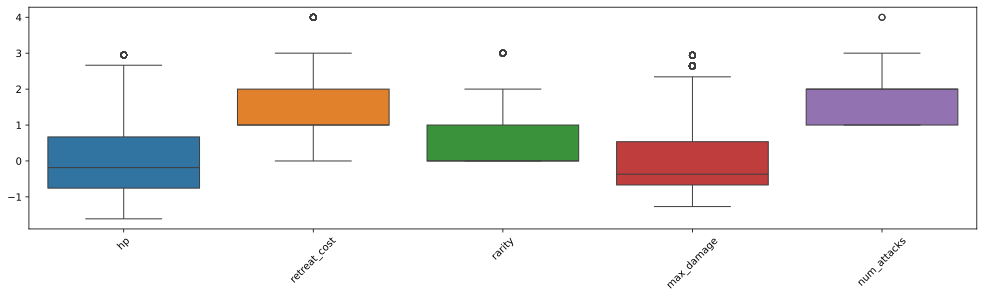

In [9]:
# The distribution of data after normalized
fig,ax = plt.subplots(1,figsize=(17,4))
colsToDisplay = ['hp', 'retreat_cost', 'rarity', 'max_damage', 'num_attacks']
ax = sns.boxplot(data=dataT[colsToDisplay])
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)
plt.show()

# Test-Train Split


In [10]:
# Separate data into features and labels
labels = torch.tensor(dataT['rarity'].values).float()
labels = labels[:, None]
features = torch.tensor(dataT.drop(labels='rarity', axis=1).values).float()

In [11]:
# split data into 95% training, 5% testing
train_data,test_data, train_labels,test_labels = train_test_split(features, labels, test_size=0.05)

# Convert them into TensorDataset
train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

# Put into Dataloaders for mini-batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

# Deep Learning Model


In [13]:
# THE MODEL
class RarityPredictor(nn.Module):
    def __init__(self):
        super().__init__()

        ### input layer
        self.input = nn.Linear(31,64)
        
        ### hidden layers
        self.bnorm1 = nn.BatchNorm1d(64) # the number of units into fc1
        self.fc1    = nn.Linear(64,32)
        self.bnorm2 = nn.BatchNorm1d(32)
        self.fc2    = nn.Linear(32,16)
        self.bnorm3 = nn.BatchNorm1d(16)
        self.fc3    = nn.Linear(16,8)
        
        ### output layer
        self.output = nn.Linear(8,4)

        ### Activation Function
        self.actFun = nn.LeakyReLU()  

    # forward pass
    def forward(self, x):

        # input
        x = self.actFun( self.input(x) )
        x = F.dropout(x,p=0.2,training=self.training)
        
        # hidden layers: BatchNorm → Linear → ReLU → Dropout
        x = self.actFun(self.fc1(self.bnorm1(x)))
        x = F.dropout(x,p=0.2,training=self.training)
        x = self.actFun(self.fc2(self.bnorm2(x)))
        x = F.dropout(x,p=0.2,training=self.training)
        x = self.actFun(self.fc3(self.bnorm3(x)))

        # output layer
        return self.output(x)

In [14]:
# Experiment to make sure the model works
model = RarityPredictor()
X, y = next(iter(test_loader))
yhat = model(X)
print(X.shape)
print(torch.softmax(yhat,dim=1))

torch.Size([610, 31])
tensor([[0.2327, 0.2899, 0.2451, 0.2323],
        [0.2246, 0.3063, 0.2424, 0.2267],
        [0.2623, 0.2953, 0.2286, 0.2138],
        ...,
        [0.2667, 0.2994, 0.2253, 0.2087],
        [0.2836, 0.3971, 0.1639, 0.1554],
        [0.2257, 0.3096, 0.2526, 0.2121]], grad_fn=<SoftmaxBackward0>)


# Finally, train & evaluate


In [15]:
# a function that trains the model
def trainModel():
    
    # number of epochs
    numepochs = 200

    # initialize meta-parameters
    model = RarityPredictor()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=25)
    lossfun = nn.CrossEntropyLoss()

    # initialize results to be visualized
    trainLoss = []
    testLoss = []
    trainAcc = []
    testAcc = []

    # loop over epochs
    for epochi in range(numepochs):

        # switch on training mode
        model.train()

        # loop over training data batches
        batchAcc = []
        batchLoss = []

        for X, y in train_loader:

            y = y.squeeze().long()
            # forward pass and compute loss
            yHat = model(X)
            loss = lossfun(yHat, y)

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
                        
            # loss from this batch
            batchLoss.append(loss.item())

            # compute accuracy
            matches = torch.argmax(yHat, dim=1) == y
            matchesNumeric = matches.float()
            accuracyPct = 100 * torch.mean(matchesNumeric)
            batchAcc.append(accuracyPct)

        # now that we've trained through the batches, get their average training accuracy
        trainAcc.append(np.mean(batchAcc))

        # and get average losses across the batches
        trainLoss.append(np.mean(batchLoss))

        # test accuracy
        model.eval()
        X, y = next(iter(test_loader))
        y = y.squeeze().long()
        with torch.no_grad():
            yHat = model(X)
            loss = lossfun(yHat, y).item() 
            testLoss.append(loss)
        
        acc = 100 * torch.mean((torch.argmax(yHat, dim=1) == y).float()).item()
        testAcc.append(round(acc, 5))
        last_lr = optimizer.param_groups[0]['lr']

        # Learning rate decay
        scheduler.step(loss)

        # print status message
        if ((epochi+1) % 20 == 0): print(f"Epoch {epochi+1} | LR after step: {last_lr}")

    # function output
    return trainAcc, testAcc, trainLoss, testLoss, model


In [16]:
# Compute Accuracy & Loss
trainAcc, testAcc, trainLoss, testLoss, model = trainModel()
# print(trainAcc)
# print(testAcc)
# print(trainLoss)
# print(testLoss)

Epoch 20 | LR after step: 0.001
Epoch 40 | LR after step: 0.001
Epoch 60 | LR after step: 0.001
Epoch 80 | LR after step: 0.001
Epoch 100 | LR after step: 0.001
Epoch 120 | LR after step: 0.0005
Epoch 140 | LR after step: 0.0005
Epoch 160 | LR after step: 0.0005
Epoch 180 | LR after step: 0.00025
Epoch 200 | LR after step: 0.00025


In [17]:
# Experiment model again
X, y = next(iter(test_loader))
yhat = model(X)
torch.softmax(yhat,dim=1)

tensor([[4.7148e-01, 5.2622e-01, 2.2650e-03, 3.3422e-05],
        [6.4689e-01, 3.3159e-01, 2.1035e-02, 4.8511e-04],
        [6.6096e-01, 3.1070e-01, 2.6697e-02, 1.6489e-03],
        ...,
        [9.7346e-01, 2.4908e-02, 1.6024e-03, 3.2758e-05],
        [2.1101e-03, 6.4538e-01, 3.3876e-01, 1.3755e-02],
        [6.6224e-01, 2.2723e-01, 1.4858e-03, 1.0905e-01]],
       grad_fn=<SoftmaxBackward0>)

# Data Visualization II


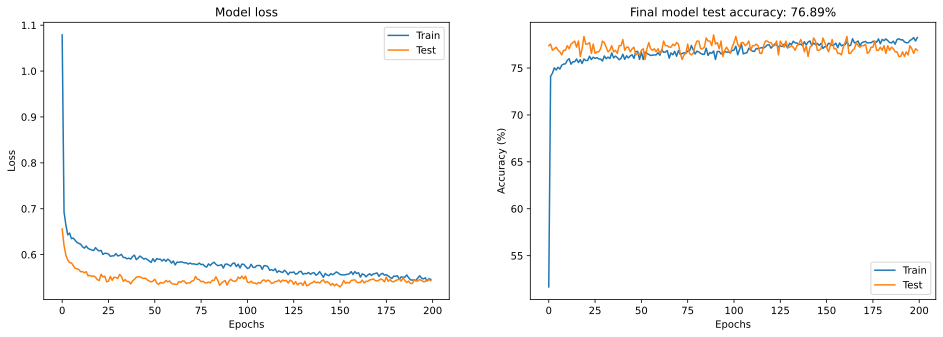

In [18]:
# Plot accuracy & loss
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(trainLoss,label='Train')
ax[0].plot(testLoss,label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend()

ax[1].plot(trainAcc,label='Train')
ax[1].plot(testAcc,label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()

plt.show()